In [1]:
import numpy as np

center = np.random.uniform(0, 100, 3)

X0 = np.random.normal(center[0],5,100).reshape(-1,2)
X1 = np.random.normal(center[1],5,100).reshape(-1,2)
X2 = np.random.normal(center[2],5,100).reshape(-1,2)

X = np.vstack([X0, X1, X2])#합치기

#랜덤하게 섞기
idx = np.random.choice(150, size=150, replace=False)
X = X[idx,:]

X[:10]

array([[87.78442035, 94.0342144 ],
       [56.47207485, 54.83884069],
       [89.28163855, 92.3266502 ],
       [58.66180389, 51.31773279],
       [88.93706098, 89.23803529],
       [48.7688448 , 49.62272227],
       [55.95175403, 48.20738331],
       [46.25086163, 39.53986532],
       [43.75855109, 48.14181147],
       [54.59891988, 51.65525629]])

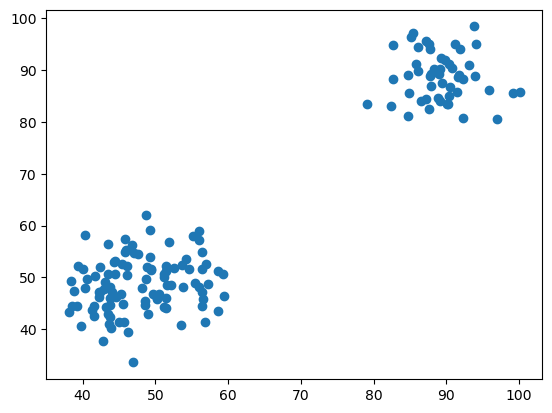

In [2]:
import matplotlib.pyplot as plt

plt.scatter(X[:,0], X[:,1])
plt.show()

In [3]:
from sklearn.cluster import KMeans

km = KMeans(n_clusters=3,
            init='random',
            n_init=10,
            max_iter=300,
            tol=1e-04,
            random_state=0)

y_km = km.fit_predict(X)
y_km#각 데이터 별 cluster number

C:\Users\DANA-LAB\.conda\envs\ml\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


array([0, 1, 0, 1, 0, 1, 1, 2, 2, 1, 2, 1, 0, 1, 1, 2, 2, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 2, 2, 0, 1, 2, 1, 0, 1, 1, 1, 1, 0, 1, 2, 0, 0, 0, 0,
       0, 0, 2, 0, 0, 1, 2, 0, 2, 2, 2, 2, 1, 2, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 1, 2, 2, 0, 0, 2, 1, 1, 2, 0, 1, 1, 2, 2, 2, 0, 1, 2,
       0, 0, 2, 1, 2, 0, 1, 2, 2, 2, 1, 2, 0, 2, 0, 0, 1, 0, 1, 2, 1, 2,
       1, 0, 0, 2, 2, 2, 2, 1, 0, 1, 2, 1, 2, 0, 0, 0, 0, 1, 2, 2, 1, 2,
       1, 0, 2, 2, 2, 2, 0, 1, 1, 0, 2, 2, 1, 0, 1, 2, 0, 0])

In [4]:
km.cluster_centers_

array([[89.22718973, 88.78805351],
       [52.47781359, 50.72861536],
       [43.1599373 , 46.5325717 ]])

In [5]:
for i in range(3):
    print(np.mean(X[y_km==i,:],axis=0))

[89.22718973 88.78805351]
[52.47781359 50.72861536]
[43.1599373 46.5325717]


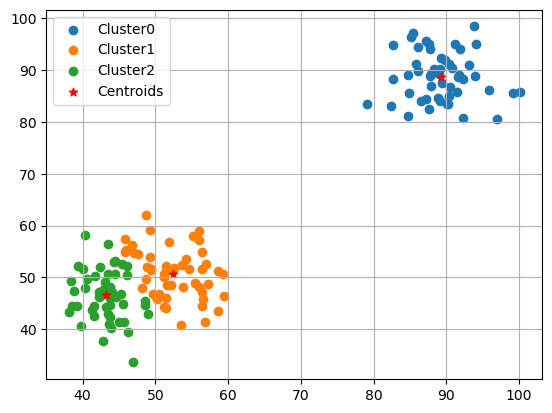

In [6]:
cluster = np.unique(y_km) #클러스터 넘버
for n in cluster:
    plt.scatter(X[y_km == n, 0],
                X[y_km == n, 1],
                label='Cluster'+str(n))

plt.scatter(km.cluster_centers_[:, 0],
            km.cluster_centers_[:, 1],
            marker='*', c='red', label='Centroids')
plt.legend()
plt.grid()
plt.show()

In [7]:
kmp = KMeans(n_clusters=3,
            init='k-means++',
            n_init=10,
            max_iter=300,
            tol=1e-04,
            random_state=0)
kmp.fit(X) #학습

C:\Users\DANA-LAB\.conda\envs\ml\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3, n_init=10, random_state=0)

In [8]:
print('Base SSE: %.2f' % km.inertia_)
print('k-mean++ SSE: %.2f' % kmp.inertia_)

Base SSE: 5251.81
k-mean++ SSE: 5252.23


C:\Users\DANA-LAB\.conda\envs\ml\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DANA-LAB\.conda\envs\ml\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DANA-LAB\.conda\envs\ml\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DANA-LAB\.conda\envs\ml\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known

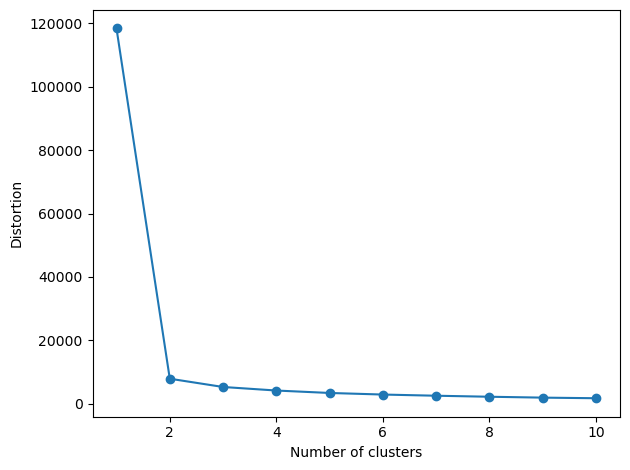

In [9]:
distortions = []
for i in range(1, 11):
    km = KMeans(n_clusters=i,
                init='k-means++',
                n_init=10,
                max_iter=300,
                random_state=0)
    km.fit(X)
    distortions.append(km.inertia_)
plt.plot(range(1, 11), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.tight_layout()
plt.show()

In [10]:
from sklearn.metrics import silhouette_score
kmp = KMeans(n_clusters=3,
            init='k-means++',
            n_init=10,
            max_iter=300,
            tol=1e-04,
            random_state=0)
kmp.fit(X) #학습
y_km = kmp.predict(X)#예측 클러스터

silhouette_score(X,y_km)

C:\Users\DANA-LAB\.conda\envs\ml\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


0.5411965189857666

In [11]:
from sklearn.metrics import silhouette_samples
silhouette_vals = silhouette_samples(X, y_km)
silhouette_avg = np.mean(silhouette_vals)

print(silhouette_vals)
print(silhouette_avg)

[0.86818592 0.51817544 0.88596977 0.51925631 0.89622571 0.14433433
 0.50976482 0.36837381 0.51639527 0.54827404 0.51833973 0.38749339
 0.76869074 0.39477276 0.44014447 0.4617694  0.46613036 0.87245868
 0.80160701 0.02882754 0.84276833 0.10260178 0.29893246 0.52187912
 0.80873866 0.12093859 0.5623198  0.38966393 0.85583676 0.47602836
 0.11560483 0.31783794 0.88522394 0.35887063 0.51444625 0.44096664
 0.50520092 0.86643506 0.26295906 0.52305285 0.85190278 0.89213431
 0.89217955 0.89114629 0.89346704 0.89102169 0.42767732 0.8286729
 0.80022671 0.02094034 0.56983456 0.8723561  0.57171823 0.55076192
 0.34689953 0.56287044 0.19736695 0.59857523 0.70160533 0.77157153
 0.43405428 0.53668254 0.15839594 0.89591821 0.46517852 0.85368648
 0.82025056 0.89213173 0.51110017 0.47840497 0.33472811 0.58783976
 0.19563896 0.82415512 0.89011791 0.49852274 0.24164924 0.45953153
 0.41267584 0.85894432 0.42883693 0.48073564 0.52712449 0.50835335
 0.18089545 0.8427102  0.45615791 0.0711645  0.88866799 0.88351

In [12]:
#필요한 패키지 준비
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [13]:
# 데이터 로딩
url = "https://gist.githubusercontent.com/pravalliyaram/5c05f43d2351249927b8a3f3cc3e5ecf/raw/8bd6144a87988213693754baaa13fb204933282d/Mall_Customers.csv"
df = pd.read_csv(url)
df.head(3)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


In [14]:
#1)CusmtomerID열 제거
df.drop("CustomerID",axis=1,inplace=True)

#2)Gender열
df["Gender"]=df["Gender"].astype('category')#Gender열 category type 지정 
df = pd.get_dummies(df) #Gender열만 원 핫 인코딩

#3)MinMax 정규화
X = MinMaxScaler().fit_transform(df) #df에 적용

print(df.columns)
X[:5,]

Index(['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Female',
       'Gender_Male'],
      dtype='object')


array([[0.01923077, 0.        , 0.3877551 , 0.        , 1.        ],
       [0.05769231, 0.        , 0.81632653, 0.        , 1.        ],
       [0.03846154, 0.00819672, 0.05102041, 1.        , 0.        ],
       [0.09615385, 0.00819672, 0.7755102 , 1.        , 0.        ],
       [0.25      , 0.01639344, 0.39795918, 1.        , 0.        ]])

C:\Users\DANA-LAB\.conda\envs\ml\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DANA-LAB\.conda\envs\ml\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DANA-LAB\.conda\envs\ml\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\DANA-LAB\.conda\envs\ml\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known

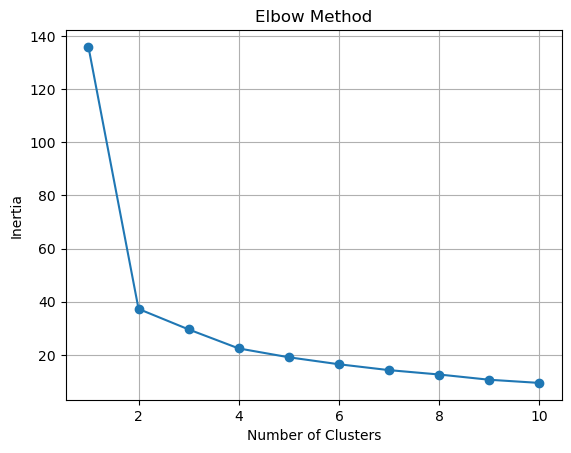

In [15]:
inertias = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

#그래프
plt.plot(range(1, 11), inertias, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid()
plt.show()

In [16]:
#차이가 큰 인덱스 
arr = np.array(inertias)
diffs = np.diff(arr) #원소간의 차
diffs = np.abs(diffs) #절대값
n=np.argmax(diffs)+2 

print(diffs)
print(f"최적의 n 개수: {n}")

[98.68920975  7.7194148   7.1618976   3.32811909  2.63316769  2.20789498
  1.64789693  1.97344834  1.19654184]
최적의 n 개수: 2


In [17]:
# KMeans 
kmeans = KMeans(n_clusters=n,
            init='k-means++',
            n_init=10,
            max_iter=300,
            tol=1e-04,
            random_state=0)
labels = kmeans.fit_predict(X)
print(labels)

[0 0 1 1 1 1 1 1 0 1 0 1 1 1 0 0 1 0 0 1 0 0 1 0 1 0 1 0 1 1 0 1 0 0 1 1 1
 1 1 1 1 0 0 1 1 1 1 1 1 1 1 0 1 0 1 0 1 0 1 0 0 0 1 1 0 0 1 1 0 1 0 1 1 1
 0 0 1 0 1 1 0 0 0 1 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0
 1 1 0 1 1 1 1 1 1 0 1 1 0 1 1 0 0 0 0 0 0 1 1 0 1 1 0 0 1 1 0 1 1 0 0 0 1
 1 0 0 0 1 1 1 1 0 1 0 1 1 1 0 1 0 1 0 1 1 0 0 0 0 0 1 1 0 0 0 0 1 1 0 1 1
 0 1 0 1 1 1 1 0 1 1 1 1 0 0 0]


C:\Users\DANA-LAB\.conda\envs\ml\lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [18]:
pd.DataFrame(kmeans.cluster_centers_,columns = df.columns)

,Age,Annual Income (k$),Spending Score (1-100),Gender_Female,Gender_Male
0,0.419362,0.387109,0.484810,-4.440892e-16,1.000000e+00
1,0.386504,0.362705,0.515579,1.000000e+00,4.440892e-16


In [19]:
silhouette_score(X, labels)

0.6346497426496239

In [20]:
result = df.copy()
result["cluster"] = labels
result.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender_Female,Gender_Male,cluster
0,19,15,39,False,True,0
1,21,15,81,False,True,0
2,20,16,6,True,False,1
3,23,16,77,True,False,1
4,31,17,40,True,False,1


In [21]:
temp = (result["Gender_Female"] == result["cluster"]) 
np.mean(temp)

1.0